In [1]:
import tensorflow as tf
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path
import flammkuchen as fl
import seaborn as sns
import pandas as pd

#from kapre.utils import Normalization2D
from kapre.composed import get_melspectrogram_layer
from kapre import STFT, Magnitude, MagnitudeToDecibel, ApplyFilterbank

from datasets.get_datasets import get_datasets

2023-01-25 13:34:47.715534: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-01-25 13:34:48.272596: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/rgroh/anaconda3/envs/evo_nas/lib/
2023-01-25 13:34:48.272649: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/rgroh/anaconda3/envs/evo_nas/lib/
2023-01-25 13:34:48.272654: W tensorflow/compile

In [2]:
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2023-01-25 13:27:35.573287: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-25 13:27:35.577340: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-25 13:27:35.577495: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [2]:
def get_resnet_model(input_length=16000, n_fft=512):
    #sr = 16000
    #mel_spec_layers = get_melspectrogram_layer(n_fft=1024, hop_length=64, sample_rate=sr, n_mels=80,
                        #mel_f_min=40.0, mel_f_max=sr / 2, db_ref_value=1.0, return_decibel=False, name='mel_stft')
    
    inputs = tf.keras.Input(shape=(input_length, 1))
    
    #x = tf.keras.layers.Lambda(lambda _x: _x[::, ::2, ::])(inputs)
    
    #x = mel_spec_layers.layers[0](x)
    #for l in mel_spec_layers.layers[1::]:
        #x = l(x)     
    
    x = STFT(n_fft=n_fft, hop_length=128, input_data_format='channels_last', output_data_format='channels_last')(inputs)
    x = Magnitude()(x)
    
    x = tf.keras.layers.Lambda(lambda _x: tf.repeat(_x, repeats=[3], axis=3))(x)
    
    resnet50 = tf.keras.applications.resnet50.ResNet50(include_top=False, input_tensor=x, weights=None)
    
    x = tf.keras.layers.GlobalAveragePooling2D()(resnet50.output)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss=tf.keras.losses.CategoricalCrossentropy(),
                  metrics='accuracy')

    #model.summary()
    
    return model

In [3]:
def exp_scheduler(epoch, lr):
    if epoch < 20:
        return 0.001
    elif epoch < 40:
        return 0.0001
    elif epoch < 60:
        return 0.00001
    else:
        return lr * np.exp(-0.1)

lr_callback = tf.keras.callbacks.LearningRateScheduler(schedule=exp_scheduler, verbose=1)

In [17]:
ds_train, ds_val, ds_test = get_datasets("motion_sense", 4_000)
model = get_resnet_model(4_000, 512)

In [18]:
history = model.fit(ds_train.batch(32), validation_data=ds_val.batch(16), epochs=100, callbacks=[lr_callback])


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/100
9/9 [==============================] - 18s 199ms/step - loss: 4.1562 - accuracy: 0.1519 - val_loss: 264.6829 - val_accuracy: 0.1333 - lr: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/100
9/9 [==============================] - 0s 41ms/step - loss: 2.0760 - accuracy: 0.2222 - val_loss: 376.4882 - val_accuracy: 0.2444 - lr: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/100
9/9 [==============================] - 0s 42ms/step - loss: 1.6329 - accuracy: 0.2741 - val_loss: 322.1903 - val_accuracy: 0.2000 - lr: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/100
9/9 [==============================] - 0s 40ms/step - loss: 1.5124 - accuracy: 0.3556 - val_loss: 131.4596 - val_accuracy: 0.1333 - lr: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.001.
Epoch 5/100
9/9 [==============================] - 0s 41ms

Epoch 38/100
9/9 [==============================] - 0s 44ms/step - loss: 0.7198 - accuracy: 0.7519 - val_loss: 1.2506 - val_accuracy: 0.4000 - lr: 1.0000e-04

Epoch 39: LearningRateScheduler setting learning rate to 0.0001.
Epoch 39/100
9/9 [==============================] - 0s 40ms/step - loss: 0.7047 - accuracy: 0.7593 - val_loss: 1.3107 - val_accuracy: 0.3556 - lr: 1.0000e-04

Epoch 40: LearningRateScheduler setting learning rate to 0.0001.
Epoch 40/100
9/9 [==============================] - 0s 37ms/step - loss: 0.6859 - accuracy: 0.7667 - val_loss: 1.2983 - val_accuracy: 0.3556 - lr: 1.0000e-04

Epoch 41: LearningRateScheduler setting learning rate to 1e-05.
Epoch 41/100
9/9 [==============================] - 0s 40ms/step - loss: 0.6671 - accuracy: 0.7704 - val_loss: 1.2576 - val_accuracy: 0.4000 - lr: 1.0000e-05

Epoch 42: LearningRateScheduler setting learning rate to 1e-05.
Epoch 42/100
9/9 [==============================] - 0s 40ms/step - loss: 0.6639 - accuracy: 0.7704 - val_l

Epoch 74/100
9/9 [==============================] - 0s 41ms/step - loss: 0.6099 - accuracy: 0.8407 - val_loss: 1.1437 - val_accuracy: 0.4889 - lr: 2.4660e-06

Epoch 75: LearningRateScheduler setting learning rate to 2.2313011552173162e-06.
Epoch 75/100
9/9 [==============================] - 0s 40ms/step - loss: 0.6094 - accuracy: 0.8407 - val_loss: 1.1418 - val_accuracy: 0.4889 - lr: 2.2313e-06

Epoch 76: LearningRateScheduler setting learning rate to 2.0189647224655964e-06.
Epoch 76/100
9/9 [==============================] - 0s 41ms/step - loss: 0.6089 - accuracy: 0.8407 - val_loss: 1.1403 - val_accuracy: 0.4889 - lr: 2.0190e-06

Epoch 77: LearningRateScheduler setting learning rate to 1.8268348772580158e-06.
Epoch 77/100
9/9 [==============================] - 0s 42ms/step - loss: 0.6085 - accuracy: 0.8407 - val_loss: 1.1394 - val_accuracy: 0.4889 - lr: 1.8268e-06

Epoch 78: LearningRateScheduler setting learning rate to 1.6529886032451501e-06.
Epoch 78/100
9/9 [======================

In [15]:
model.evaluate(ds_test.batch(16))

3/3 [==============================] - 0s 16ms/step - loss: 0.8533 - accuracy: 0.6222


[0.8533167243003845, 0.6222222447395325]

In [4]:
#samples = [3_000, 4_000, 6_000, 8_000, 16_000] # in Hz
#n_ffts = [128, 256, 512, 1024]
samples = [3_000, 4_000, 5_000, 6_000]
n_ffts = [256, 512, 1024]
#classes_filter = [0, 2, 6, 8]

save = True

results_folder = Path("Results/ResNet_results_motion_sense")

for i in range(1):
    for nb_samples in samples:
        for n_fft in n_ffts:
            ds_train, ds_val, ds_test = get_datasets("motion_sense", nb_samples)
            model = get_resnet_model(nb_samples, n_fft)
    
            history = model.fit(ds_train.batch(32), validation_data=ds_val.batch(16), epochs=100, callbacks=[lr_callback])
            test_loss, test_acc = model.evaluate(ds_test.batch(16))
            
            if save:
                # save trained model
                model.save(results_folder/ f"samples_{nb_samples}_nfft_{n_fft}" / f"model_{i}.h5")
            
                # save history and test accuracy
                d = {"val_loss": history.history["val_loss"], "train_loss": history.history["loss"], 
                     "val_accuracy": history.history["val_accuracy"], "train_accuracy": history.history["accuracy"], 
                     "test_accuracy": test_acc}
                fl.save(results_folder / f"samples_{nb_samples}_nfft_{n_fft}" / f"results_{i}.fl", d)

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


2023-01-25 13:34:55.273079: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-25 13:34:55.276775: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-25 13:34:55.276943: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-25 13:34:55.277314: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorF


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/100


2023-01-25 13:35:04.920287: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8100
2023-01-25 13:35:05.389406: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-25 13:35:06.087785: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-01-25 13:35:06.089508: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x7f2b7dbfdab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-01-25 13:35:06.089522: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2023-01-25 13:35:06.092760: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-01-25 13:35:06.13880

9/9 [==============================] - 22s 206ms/step - loss: 5.8369 - accuracy: 0.1926 - val_loss: 163.5183 - val_accuracy: 0.1333 - lr: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/100
9/9 [==============================] - 0s 40ms/step - loss: 2.1483 - accuracy: 0.1852 - val_loss: 376.3309 - val_accuracy: 0.2000 - lr: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/100
9/9 [==============================] - 0s 41ms/step - loss: 1.7246 - accuracy: 0.3185 - val_loss: 281.3910 - val_accuracy: 0.2000 - lr: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/100
9/9 [==============================] - 0s 39ms/step - loss: 1.5674 - accuracy: 0.3037 - val_loss: 119.2612 - val_accuracy: 0.2000 - lr: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.001.
Epoch 5/100
9/9 [==============================] - 0s 40ms/step - loss: 1.4781 - accuracy: 0.3111 - val_loss: 44.5522 - val_accuracy: 

...

9/9 [==============================] - 0s 44ms/step - loss: 0.3716 - accuracy: 0.9333 - val_loss: 1.6322 - val_accuracy: 0.3556 - lr: 1.0000e-04

Epoch 39: LearningRateScheduler setting learning rate to 0.0001.
Epoch 39/100
9/9 [==============================] - 0s 45ms/step - loss: 0.4063 - accuracy: 0.9037 - val_loss: 1.4914 - val_accuracy: 0.4444 - lr: 1.0000e-04

Epoch 40: LearningRateScheduler setting learning rate to 0.0001.
Epoch 40/100
9/9 [==============================] - 0s 45ms/step - loss: 0.3826 - accuracy: 0.9074 - val_loss: 1.5505 - val_accuracy: 0.4000 - lr: 1.0000e-04

Epoch 41: LearningRateScheduler setting learning rate to 1e-05.
Epoch 41/100
9/9 [==============================] - 0s 44ms/step - loss: 0.3845 - accuracy: 0.8815 - val_loss: 1.5061 - val_accuracy: 0.4000 - lr: 1.0000e-05

Epoch 42: LearningRateScheduler setting learning rate to 1e-05.
Epoch 42/100
9/9 [==============================] - 0s 46ms/step - loss: 0.3549 - accuracy: 0.8926 - val_loss: 1.4592 -

Epoch 74/100
9/9 [==============================] - 0s 44ms/step - loss: 0.1992 - accuracy: 0.9889 - val_loss: 1.4511 - val_accuracy: 0.5556 - lr: 2.4660e-06

Epoch 75: LearningRateScheduler setting learning rate to 2.2313011552173162e-06.
Epoch 75/100
9/9 [==============================] - 0s 43ms/step - loss: 0.1983 - accuracy: 0.9889 - val_loss: 1.4605 - val_accuracy: 0.5556 - lr: 2.2313e-06

Epoch 76: LearningRateScheduler setting learning rate to 2.0189647224655964e-06.
Epoch 76/100
9/9 [==============================] - 0s 42ms/step - loss: 0.1975 - accuracy: 0.9889 - val_loss: 1.4688 - val_accuracy: 0.5556 - lr: 2.0190e-06

Epoch 77: LearningRateScheduler setting learning rate to 1.8268348772580158e-06.
Epoch 77/100
9/9 [==============================] - 0s 43ms/step - loss: 0.1968 - accuracy: 0.9889 - val_loss: 1.4758 - val_accuracy: 0.5556 - lr: 1.8268e-06

Epoch 78: LearningRateScheduler setting learning rate to 1.6529886032451501e-06.
Epoch 78/100
9/9 [======================


Epoch 9: LearningRateScheduler setting learning rate to 0.001.
Epoch 9/100
9/9 [==============================] - 1s 57ms/step - loss: 1.2404 - accuracy: 0.3519 - val_loss: 1.6147 - val_accuracy: 0.1333 - lr: 0.0010

Epoch 10: LearningRateScheduler setting learning rate to 0.001.
Epoch 10/100
9/9 [==============================] - 1s 57ms/step - loss: 1.3954 - accuracy: 0.3148 - val_loss: 2.0505 - val_accuracy: 0.1333 - lr: 0.0010

Epoch 11: LearningRateScheduler setting learning rate to 0.001.
Epoch 11/100
9/9 [==============================] - 1s 57ms/step - loss: 1.3022 - accuracy: 0.2926 - val_loss: 1.4039 - val_accuracy: 0.2667 - lr: 0.0010

Epoch 12: LearningRateScheduler setting learning rate to 0.001.
Epoch 12/100
9/9 [==============================] - 1s 56ms/step - loss: 1.2111 - accuracy: 0.4481 - val_loss: 1.4103 - val_accuracy: 0.1778 - lr: 0.0010

Epoch 13: LearningRateScheduler setting learning rate to 0.001.
Epoch 13/100
9/9 [==============================] - 1s 58ms/s


Epoch 46: LearningRateScheduler setting learning rate to 1e-05.
Epoch 46/100
9/9 [==============================] - 1s 56ms/step - loss: 0.3632 - accuracy: 0.9111 - val_loss: 1.1339 - val_accuracy: 0.4444 - lr: 1.0000e-05

Epoch 47: LearningRateScheduler setting learning rate to 1e-05.
Epoch 47/100
9/9 [==============================] - 1s 58ms/step - loss: 0.3616 - accuracy: 0.9111 - val_loss: 1.0822 - val_accuracy: 0.4444 - lr: 1.0000e-05

Epoch 48: LearningRateScheduler setting learning rate to 1e-05.
Epoch 48/100
9/9 [==============================] - 1s 58ms/step - loss: 0.3601 - accuracy: 0.9148 - val_loss: 1.0296 - val_accuracy: 0.5111 - lr: 1.0000e-05

Epoch 49: LearningRateScheduler setting learning rate to 1e-05.
Epoch 49/100
9/9 [==============================] - 1s 58ms/step - loss: 0.3585 - accuracy: 0.9148 - val_loss: 0.9826 - val_accuracy: 0.5111 - lr: 1.0000e-05

Epoch 50: LearningRateScheduler setting learning rate to 1e-05.
Epoch 50/100
9/9 [=========================

Epoch 81/100
9/9 [==============================] - 1s 58ms/step - loss: 0.3236 - accuracy: 0.9259 - val_loss: 0.6419 - val_accuracy: 0.6222 - lr: 1.2246e-06

Epoch 82: LearningRateScheduler setting learning rate to 1.1080314456971988e-06.
Epoch 82/100
9/9 [==============================] - 1s 57ms/step - loss: 0.3234 - accuracy: 0.9259 - val_loss: 0.6414 - val_accuracy: 0.6222 - lr: 1.1080e-06

Epoch 83: LearningRateScheduler setting learning rate to 1.0025883465914306e-06.
Epoch 83/100
9/9 [==============================] - 1s 58ms/step - loss: 0.3232 - accuracy: 0.9259 - val_loss: 0.6407 - val_accuracy: 0.6222 - lr: 1.0026e-06

Epoch 84: LearningRateScheduler setting learning rate to 9.071794138913676e-07.
Epoch 84/100
9/9 [==============================] - 1s 58ms/step - loss: 0.3229 - accuracy: 0.9259 - val_loss: 0.6403 - val_accuracy: 0.6222 - lr: 9.0718e-07

Epoch 85: LearningRateScheduler setting learning rate to 8.208498772831564e-07.
Epoch 85/100
9/9 [========================

In [5]:
d_samples = {}
for nb_samples in samples:
    d_nffts = {}
    for n_fft in n_ffts:
        test_accs = []
        for i in range(3):
            results = fl.load(results_folder / f"samples_{nb_samples}_nfft_{n_fft}" / f"results_{0}.fl")
            test_accs.append(results["test_accuracy"])
        d_nffts[str(n_fft)] = np.mean(test_accs)
    d_samples[str(nb_samples)] = d_nffts   
    
df = pd.DataFrame(d_samples)
df

,3000,4000,5000,6000
256,0.377778,0.555556,0.200000,0.466667
512,0.311111,0.444444,0.422222,0.555556
1024,0.422222,0.622222,0.577778,0.644444


Text(0.5, 1.0, 'Motion Sense - ResNet50 - Test Accuracy')

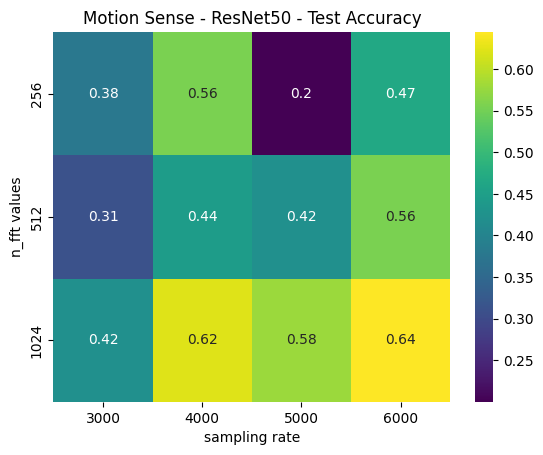

In [9]:
sns.heatmap(df, cmap="viridis", annot=True)
plt.ylabel("n_fft values")
plt.xlabel("sampling rate")
plt.title("Motion Sense - ResNet50 - Test Accuracy")

Text(0.5, 1.0, 'Test')

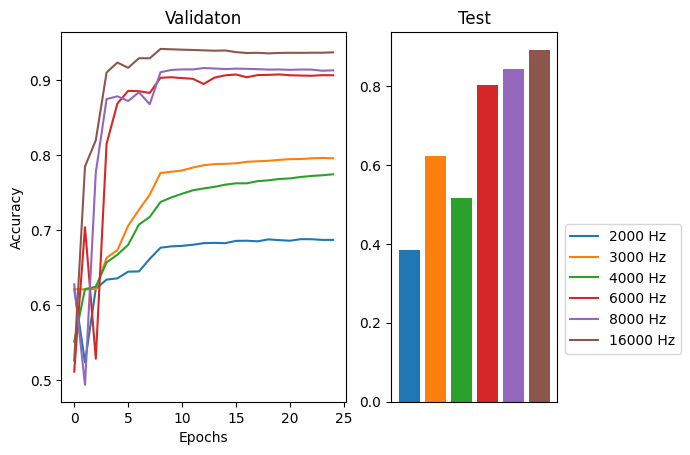

In [79]:
fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [6, 3.5]})

d = {}
for idx, (history, (test_loss, test_acc)) in enumerate(results):
    d[f"{samples[idx]} Hz"] = (history.history["val_accuracy"], test_acc)
    ax1.plot(history.history["val_accuracy"], label=f"{samples[idx]} Hz")
    ax2.bar(idx, test_acc, label=f"{samples[idx]} Hz")
    
ax1.legend(bbox_to_anchor=(0,0,2.2,0.5))
ax1.set_ylabel("Accuracy")
ax1.set_xlabel("Epochs")
ax1.set_title("Validaton")
#ax1.set_ylim([0.3, 1])

ax2.set_xticks([])
#ax2.set_yticks([])
#ax2.set_ylim([0., 1])
ax2.set_title("Test")

In [80]:
d

{'2000 Hz': ([0.6213620901107788,
   0.5240546464920044,
   0.6219560503959656,
   0.6340328454971313,
   0.6357157230377197,
   0.6446248292922974,
   0.6449217796325684,
   0.6616511344909668,
   0.6764997243881226,
   0.6782815456390381,
   0.678974449634552,
   0.6804593205451965,
   0.6825380921363831,
   0.682934045791626,
   0.6825380921363831,
   0.685606837272644,
   0.6858047842979431,
   0.6850128769874573,
   0.6875866055488586,
   0.686596691608429,
   0.6858047842979431,
   0.6878836154937744,
   0.6877846121788025,
   0.6868937015533447,
   0.6868937015533447],
  0.384253591299057),
 '3000 Hz': ([0.6213620901107788,
   0.620867133140564,
   0.6215600967407227,
   0.6631360054016113,
   0.6731340289115906,
   0.7058008313179016,
   0.7268857359886169,
   0.7471787929534912,
   0.7759849429130554,
   0.7775688171386719,
   0.7793506383895874,
   0.7832112312316895,
   0.7862799167633057,
   0.7877647876739502,
   0.7881607413291931,
   0.7888537049293518,
   0.790833473205

In [81]:
import flammkuchen as fl
fl.save("results_resnet50_different_sr.h5", d)

/data/du92wufe/.conda/envs/airway/lib/python3.10/site-packages/tables/path.py:137: NaturalNameWarning: object name is not a valid Python identifier: '2000 Hz'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/data/du92wufe/.conda/envs/airway/lib/python3.10/site-packages/tables/path.py:137: NaturalNameWarning: object name is not a valid Python identifier: '3000 Hz'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/data/du92wufe/.conda/envs/airway/lib/python3.10/site-packages/tables/path.py:137: NaturalNameWarning: object name is not a valid Python identifier: '4000 Hz'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this obje

In [82]:
fl.load("results_resnet50_different_sr.h5")

{'16000 Hz': ([0.5264304280281067,
   0.784696102142334,
   0.8195406794548035,
   0.9097208380699158,
   0.9229855537414551,
   0.9159572124481201,
   0.9287269711494446,
   0.9286279678344727,
   0.9411007761955261,
   0.9406058192253113,
   0.9401108622550964,
   0.9397149085998535,
   0.9392199516296387,
   0.9387249946594238,
   0.9390220046043396,
   0.9368441700935364,
   0.9356563091278076,
   0.9359532594680786,
   0.9351613521575928,
   0.9357553124427795,
   0.9359532594680786,
   0.9358543157577515,
   0.9360522627830505,
   0.9360522627830505,
   0.9365472197532654],
  0.8918200135231018),
 '2000 Hz': ([0.6213620901107788,
   0.5240546464920044,
   0.6219560503959656,
   0.6340328454971313,
   0.6357157230377197,
   0.6446248292922974,
   0.6449217796325684,
   0.6616511344909668,
   0.6764997243881226,
   0.6782815456390381,
   0.678974449634552,
   0.6804593205451965,
   0.6825380921363831,
   0.682934045791626,
   0.6825380921363831,
   0.685606837272644,
   0.685804784

In [40]:
model.evaluate(ds_test.batch(128))

39/39 [==============================] - 1s 19ms/step - loss: 0.5427 - accuracy: 0.8789


[0.5426703691482544, 0.8789365887641907]

Text(0.5, 0, 'Epochs')

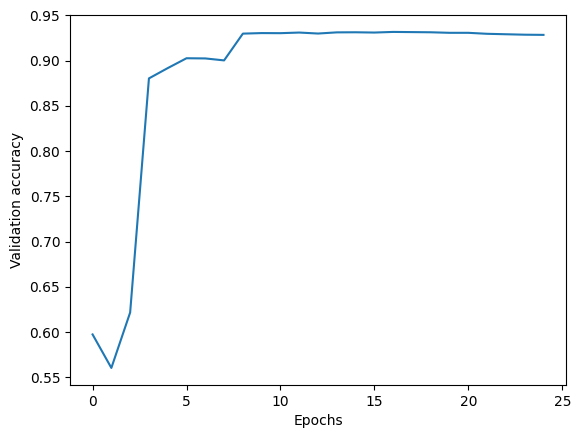

In [42]:
plt.plot(history.history['val_accuracy'])
plt.ylabel("Validation accuracy")
plt.xlabel("Epochs")